# Swing Structure & BOS Analysis Notebook
### Detects swing levels, classifies Major/Minor, scores BOS events, measures outcome.
### Phase 5A: Structure Detection | Phase 5B: BOS Scoring | Phase 5C: Score Matrix Analysis
**Run top to bottom. Paths in Cell 2 only.**

## Cell 1 — Installs & Imports

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'scipy', 'seaborn', '-q'])

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import spearmanr, mannwhitneyu
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 40)
plt.style.use('dark_background')
np.random.seed(42)
print('Imports complete.')

Imports complete.


## Cell 2 — Master Config
**All paths and parameters here. Change nothing elsewhere.**

In [2]:
# ── Cell 2: Master Config ──────────────────────────────────────────────────

CFG = {

    # ── Paths ─────────────────────────────────────────────────────────────
    # 1m klines CSV — Binance format
    'PATH_KLINES_1M'     : '/content/BTCUSDT-1m-2021-010.csv',
    # aggTrades CSV — optional, used for delta at BOS bar
    # Set None to skip delta at BOS (other scores still computed)
    'PATH_AGGTRADES'     : None,

    # ── Timeframe for structure detection ────────────────────────────────
    # Swing levels are detected on this timeframe.
    # Recommend 5m for intraday, 15m for session-level structure.
    # All values below are in bars of this timeframe.
    'STRUCTURE_TF'       : '5min',

    # ── Data window ──────────────────────────────────────────────────────
    'DAYS_TO_LOAD'       : 365,

    # ── Swing Detection ──────────────────────────────────────────────────
    # Strict 3-bar rule:
    #   Swing High: bar[i].high > bar[i-1].high AND bar[i].high > bar[i+1].high
    #   Swing Low : bar[i].low  < bar[i-1].low  AND bar[i].low  < bar[i+1].low
    # Confirmed only after bar[i+1] closes — one bar lag, no lookahead.
    # SWING_EQUAL_TOLERANCE: how close two highs/lows must be to be considered equal
    # (as fraction of ATR). Set 0 for strict greater-than only.
    'SWING_EQUAL_TOL'    : 0.0,

    # ── BOS Scoring Parameters ────────────────────────────────────────────
    # Component weights — must sum to 1.0
    # displacement_score = body_ratio * W_BODY
    #                    + range_expansion_norm * W_RANGE
    #                    + vol_relative_norm * W_VOL
    'W_BODY'             : 0.35,   # candle body / total range
    'W_RANGE'            : 0.35,   # (high-low) / ATR(14), normalised to 0-1
    'W_VOL'              : 0.30,   # volume / vol_MA(20), normalised to 0-1

    # Normalisation caps — values above these are treated as maximum (1.0)
    'RANGE_EXP_CAP'      : 3.0,    # 3× ATR = max range score
    'VOL_REL_CAP'        : 3.0,    # 3× average volume = max vol score

    # Close position bonus added on top of displacement score
    # 0.0 = only wick broke the level
    # 0.2 = candle closed above/below the level
    # 0.3 = full body above/below (both open AND close beyond level)
    'CLOSE_BONUS_WICK'   : 0.00,
    'CLOSE_BONUS_CLOSE'  : 0.20,
    'CLOSE_BONUS_BODY'   : 0.30,

    # ── BOS Validity Thresholds ───────────────────────────────────────────
    # Minimum total BOS score to consider a BOS valid for Major level promotion
    # Values below this threshold are stored as WEAK_BOS
    # This threshold is INITIALLY a guess — Phase 5C will calibrate it from data
    'BOS_VALID_THRESHOLD': 0.50,

    # ── Fake BOS Detection ────────────────────────────────────────────────
    # Retracement ratio between two consecutive BOS events.
    # If the pullback between BOS-1 and BOS-2 is less than this fraction
    # of the BOS-1 leg, flag BOS-2 as potentially fake.
    'FAKE_BOS_RETRACE'   : 0.382,

    # ── Outcome Measurement ───────────────────────────────────────────────
    # After a BOS, how many bars forward to measure outcome
    'BOS_FWD_BARS'       : [6, 12, 24, 48],   # in bars of STRUCTURE_TF
    # A BOS is 'genuine' if price stays on the correct side for at least this many bars
    'BOS_GENUINE_HOLD'   : 12,
    # Price must stay this far (as fraction of BOS level price) beyond the broken level
    'BOS_HOLD_BUFFER'    : 0.001,   # 0.1% buffer

    # ── ATR / Volume windows ─────────────────────────────────────────────
    'ATR_PERIOD'         : 14,
    'VOL_MA_PERIOD'      : 20,

    # ── Output ────────────────────────────────────────────────────────────
    'SAVE_PLOTS'         : True,
    'PLOT_DPI'           : 130,
    'BG'                 : '#0d1117',
    'TEAL'               : '#00d4aa',
    'ORANGE'             : '#f7931a',
    'RED'                : '#e74c3c',
    'BLUE'               : '#3498db',
    'GREY'               : '#555555',
    'YELLOW'             : '#f1c40f',
}

print('Config loaded.')
print(f"  Structure TF : {CFG['STRUCTURE_TF']}")
print(f"  Days         : {CFG['DAYS_TO_LOAD']}")
print(f"  BOS weights  : body={CFG['W_BODY']} range={CFG['W_RANGE']} vol={CFG['W_VOL']}")
print(f"  BOS threshold: {CFG['BOS_VALID_THRESHOLD']} (will be calibrated in Phase 5C)")

Config loaded.
  Structure TF : 5min
  Days         : 365
  BOS weights  : body=0.35 range=0.35 vol=0.3
  BOS threshold: 0.5 (will be calibrated in Phase 5C)


## Cell 3 — Data Loader
Loads 1m klines, resamples to structure timeframe.
Computes ATR, volume MA, body ratio, range expansion on structure bars.

In [3]:
# ── Cell 3: Data Loader ────────────────────────────────────────────────────

KLINE_COLS = [
    'open_time','open','high','low','close','volume','close_time',
    'quote_vol','n_trades','taker_buy_base','taker_buy_quote','ignore'
]

def parse_ts(series):
    s = pd.to_numeric(series, errors='coerce').dropna().astype(np.int64)
    unit = 'us' if s.iloc[0] > 1e15 else 'ms'
    return pd.to_datetime(s, unit=unit, utc=True)

def load_klines(path):
    import os
    if not os.path.exists(path):
        raise FileNotFoundError(f'Klines file not found: {path}')
    df = pd.read_csv(path)
    if 'open_time' not in df.columns:
        df.columns = KLINE_COLS
    df = df.dropna(subset=['open_time'])
    df.index = parse_ts(df['open_time'])
    # Handle both column name variants
    taker_col = 'taker_buy_base' if 'taker_buy_base' in df.columns else 'taker_buy_volume'
    use = ['open','high','low','close','volume',taker_col]
    df = df[[c for c in use if c in df.columns]].apply(pd.to_numeric, errors='coerce')
    if taker_col != 'taker_buy_base':
        df.rename(columns={taker_col: 'taker_buy_base'}, inplace=True)
    df = df[~df.index.duplicated(keep='first')].sort_index()
    print(f'  [1m] {len(df):,} bars | {df.index[0].date()} → {df.index[-1].date()}')
    return df

def clip_days(df, days):
    if df is None: return None
    return df[df.index >= df.index[-1] - pd.Timedelta(days=days)]

def resample_klines(df1m, rule):
    return df1m.resample(rule).agg({
        'open':'first','high':'max','low':'min','close':'last',
        'volume':'sum','taker_buy_base':'sum'
    }).dropna(subset=['open'])

def compute_atr(df, period=14):
    h, l, pc = df['high'], df['low'], df['close'].shift(1)
    tr = pd.concat([h-l, (h-pc).abs(), (l-pc).abs()], axis=1).max(axis=1)
    return tr.ewm(alpha=1/period, adjust=False).mean()

print('Loading data...')
df1m_raw = load_klines(CFG['PATH_KLINES_1M'])
df1m_raw = clip_days(df1m_raw, CFG['DAYS_TO_LOAD'])

# Build structure timeframe
df_struct = resample_klines(df1m_raw, CFG['STRUCTURE_TF'])
print(f'  [{CFG["STRUCTURE_TF"]}] {len(df_struct):,} bars')

# ── Pre-compute bar features used in BOS scoring ──────────────────────────
df_struct['atr']       = compute_atr(df_struct, CFG['ATR_PERIOD'])
df_struct['vol_ma']    = df_struct['volume'].rolling(CFG['VOL_MA_PERIOD']).mean()
df_struct['vol_rel']   = df_struct['volume'] / (df_struct['vol_ma'] + 1e-10)
df_struct['bar_range'] = df_struct['high'] - df_struct['low']
df_struct['body']      = (df_struct['close'] - df_struct['open']).abs()
df_struct['body_ratio'] = df_struct['body'] / (df_struct['bar_range'] + 1e-10)
df_struct['range_exp']  = df_struct['bar_range'] / (df_struct['atr'] + 1e-10)
df_struct['taker_ratio'] = df_struct['taker_buy_base'] / (df_struct['volume'] + 1e-10)
df_struct['log_ret']    = np.log(df_struct['close'] / df_struct['close'].shift(1))
df_struct = df_struct.dropna(subset=['atr','vol_ma'])

print(f'Structure bars after warmup: {len(df_struct):,}')
print(f'Date range: {df_struct.index[0].date()} → {df_struct.index[-1].date()}')

Loading data...
  [1m] 525,588 bars | 2021-01-01 → 2021-12-31
  in] 105,120 bars
Structure bars after warmup: 105,101
Date range: 2021-01-01 → 2021-12-31


## Phase 5A — Swing Detection & Major/Minor Classification

**Swing detection rule (strictly 3-bar):**
- Swing High: `bar[i].high > bar[i-1].high AND bar[i].high > bar[i+1].high`
- Swing Low: `bar[i].low < bar[i-1].low AND bar[i].low < bar[i+1].low`
- Confirmed only after bar[i+1] closes. One-bar lag. No lookahead.

**Major/Minor classification:**
- Tracks the running list of confirmed Major Swing Highs and Lows
- A BOS occurs when price closes beyond the most recent Major level
- On BOS: the lowest swing low of the leg (for bullish BOS) becomes the new Major Swing Low
- All other swing highs/lows are Minor
- Major Swing Low label is assigned retroactively to the lowest swing low of the breakout leg

In [4]:
# ── Phase 5A: Swing Detection ─────────────────────────────────────────────

def detect_swings(df):
    """
    Detect all 3-bar swing highs and lows.
    Returns two boolean Series: swing_high, swing_low.
    Confirmed at bar[i] only after bar[i+1] has closed.
    In a vectorised implementation, this means bar[i] is labelled
    using bar[i+1]'s data — which is available at bar[i+1] close time.
    No lookahead: we shift the confirmation forward by 1 bar.
    """
    highs = df['high'].values
    lows  = df['low'].values
    n     = len(df)

    sh = np.zeros(n, dtype=bool)   # swing high at bar i
    sl = np.zeros(n, dtype=bool)   # swing low at bar i

    for i in range(1, n - 1):
        if highs[i] > highs[i-1] and highs[i] > highs[i+1]:
            sh[i] = True
        if lows[i]  < lows[i-1]  and lows[i]  < lows[i+1]:
            sl[i] = True

    # The swing at bar[i] is confirmed when bar[i+1] closes.
    # Shift labels forward by 1 so they are available at bar[i+1] close.
    # This is the one-bar confirmation lag — structurally correct, no lookahead.
    sh_confirmed = np.roll(sh, 1); sh_confirmed[0] = False
    sl_confirmed = np.roll(sl, 1); sl_confirmed[0] = False

    return (
        pd.Series(sh_confirmed, index=df.index, name='swing_high'),
        pd.Series(sl_confirmed, index=df.index, name='swing_low'),
        pd.Series(sh, index=df.index, name='sh_raw'),   # raw (for price retrieval)
        pd.Series(sl, index=df.index, name='sl_raw'),
    )

print('Detecting swing levels...')
sh_conf, sl_conf, sh_raw, sl_raw = detect_swings(df_struct)
df_struct['swing_high'] = sh_conf
df_struct['swing_low']  = sl_conf
df_struct['sh_raw']     = sh_raw
df_struct['sl_raw']     = sl_raw

n_sh = sh_conf.sum()
n_sl = sl_conf.sum()
print(f'  Swing highs: {n_sh:,}')
print(f'  Swing lows : {n_sl:,}')
print(f'  Total swings: {n_sh + n_sl:,}')
print(f'  Avg bars between swings: {len(df_struct) / (n_sh + n_sl):.1f}')

Detecting swing levels...
  Swing highs: 23,925
  Swing lows : 23,691
  Total swings: 47,616
  Avg bars between swings: 2.2


In [5]:
# ── Phase 5A continued: Major/Minor Classification & BOS Detection ─────────
# State machine that walks forward bar by bar.
# Maintains: current_major_sh (price), current_major_sl (price),
#            current_trend (BULL / BEAR / UNDEFINED),
#            leg_swings (list of swing lows/highs in current leg)
#
# A BOS fires when:
#   BULL trend: a bar's HIGH exceeds current_major_sh
#   BEAR trend: a bar's LOW goes below current_major_sl
#   UNDEFINED: first BOS in either direction establishes the trend
#
# On bullish BOS:
#   - BOS bar is logged with all scoring inputs
#   - The lowest swing_low from the current leg becomes the new Major Swing Low
#   - The current bar's high (or the highest swing high of the leg) becomes candidate Major Swing High
#     (confirmed only after price pulls back from it)
#   - Leg resets
#
# On bearish BOS: mirror logic.

def classify_structure(df, cfg):
    """
    Walk forward through all bars.
    Returns:
        bos_records   : list of dicts, one per BOS event
        swing_records : list of dicts, one per confirmed swing (with major/minor label)
    """

    highs      = df['high'].values
    lows       = df['low'].values
    opens      = df['open'].values
    closes     = df['close'].values
    sh_arr     = df['swing_high'].values
    sl_arr     = df['swing_low'].values
    sh_raw_arr = df['sh_raw'].values
    sl_raw_arr = df['sl_raw'].values
    body_ratio = df['body_ratio'].values
    range_exp  = df['range_exp'].values
    vol_rel    = df['vol_rel'].values
    taker_r    = df['taker_ratio'].values
    idx        = df.index
    n          = len(df)

    # ── State ─────────────────────────────────────────────────────────────
    trend              = 'UNDEFINED'   # BULL / BEAR / UNDEFINED
    major_sh_price     = None          # current major swing high price
    major_sl_price     = None          # current major swing low price
    major_sh_bar       = None          # bar index of current major swing high
    major_sl_bar       = None          # bar index of current major swing low

    # Leg tracking: collect all swing lows (for bullish) or highs (for bearish)
    # in the current leg since the last BOS
    leg_sl_prices  = []   # (price, bar_index) for swing lows in current leg
    leg_sh_prices  = []   # (price, bar_index) for swing highs in current leg
    leg_start_bar  = 0

    bos_records    = []
    swing_records  = []

    # Score a single BOS bar
    def score_bos(bar_i, level_price, direction):
        """
        direction: +1 for bullish BOS (price broke above level),
                   -1 for bearish BOS (price broke below level)
        Returns dict of all scoring components and total score.
        """
        br   = float(body_ratio[bar_i])
        re   = float(range_exp[bar_i])
        vr   = float(vol_rel[bar_i])
        tk   = float(taker_r[bar_i])
        o    = opens[bar_i]
        c    = closes[bar_i]
        h    = highs[bar_i]
        lo   = lows[bar_i]

        # Normalised components (0 to 1)
        body_score  = br   # already 0-1
        range_score = min(re / cfg['RANGE_EXP_CAP'], 1.0)
        vol_score   = min(vr / cfg['VOL_REL_CAP'],   1.0)

        disp_score  = (body_score  * cfg['W_BODY'] +
                       range_score * cfg['W_RANGE'] +
                       vol_score   * cfg['W_VOL'])

        # Close position bonus
        if direction == 1:
            wick_broke  = h > level_price
            close_broke = c > level_price
            body_broke  = o > level_price and c > level_price
        else:
            wick_broke  = lo < level_price
            close_broke = c  < level_price
            body_broke  = o  < level_price and c < level_price

        if body_broke:
            close_bonus = cfg['CLOSE_BONUS_BODY']
            close_type  = 'BODY'
        elif close_broke:
            close_bonus = cfg['CLOSE_BONUS_CLOSE']
            close_type  = 'CLOSE'
        elif wick_broke:
            close_bonus = cfg['CLOSE_BONUS_WICK']
            close_type  = 'WICK'
        else:
            close_bonus = 0.0
            close_type  = 'NONE'

        total_score = min(disp_score + close_bonus, 1.0)

        return {
            'body_score'   : body_score,
            'range_score'  : range_score,
            'vol_score'    : vol_score,
            'disp_score'   : disp_score,
            'close_type'   : close_type,
            'close_bonus'  : close_bonus,
            'total_score'  : total_score,
            'taker_ratio'  : tk,
            'vol_rel'      : vr,
            'bar_range_atr': re,
        }

    # ── Main loop ─────────────────────────────────────────────────────────
    for i in range(1, n):

        # Collect swing levels as they are confirmed
        if sh_arr[i]:
            # bar[i-1] is the actual swing high (confirmed at bar[i] close)
            sh_price = highs[i-1]
            sh_bar   = i - 1
            leg_sh_prices.append((sh_price, sh_bar))
            swing_records.append({
                'ts'       : idx[sh_bar],
                'type'     : 'HIGH',
                'price'    : sh_price,
                'major'    : False,   # updated below if promoted
                'bar_idx'  : sh_bar,
            })

        if sl_arr[i]:
            sl_price = lows[i-1]
            sl_bar   = i - 1
            leg_sl_prices.append((sl_price, sl_bar))
            swing_records.append({
                'ts'       : idx[sl_bar],
                'type'     : 'LOW',
                'price'    : sl_price,
                'major'    : False,
                'bar_idx'  : sl_bar,
            })

        # ── BOS detection ─────────────────────────────────────────────────
        # UNDEFINED: initialise trend on first clear directional move
        if trend == 'UNDEFINED':
            if leg_sh_prices and leg_sl_prices:
                # Use the first swing high as initial major reference
                major_sh_price, major_sh_bar = leg_sh_prices[-1]
                major_sl_price, major_sl_bar = leg_sl_prices[-1]
                trend = 'RANGING'
            continue

        # Check for bullish BOS: bar[i].high > major_sh_price
        if major_sh_price is not None and highs[i] > major_sh_price:
            scores = score_bos(i, major_sh_price, +1)
            valid  = scores['total_score'] >= cfg['BOS_VALID_THRESHOLD']

            # Retracement ratio for fake BOS detection
            # Measures how deep the pullback was in the leg before this BOS
            retrace_ratio = np.nan
            if len(leg_sl_prices) >= 1 and len(leg_sh_prices) >= 1:
                leg_low   = min(p for p, _ in leg_sl_prices)
                leg_range = major_sh_price - leg_low
                if leg_range > 0:
                    deepest_retrace = major_sh_price - leg_low
                    retrace_ratio   = deepest_retrace / leg_range

            suspect_fake = (not np.isnan(retrace_ratio) and
                            retrace_ratio < cfg['FAKE_BOS_RETRACE'])

            # Find the new Major Swing Low: lowest swing low in the current leg
            new_major_sl_price = None
            new_major_sl_bar   = None
            if leg_sl_prices:
                new_major_sl_price, new_major_sl_bar = min(leg_sl_prices, key=lambda x: x[0])
                # Retroactively mark this swing low as Major
                for rec in swing_records:
                    if rec['bar_idx'] == new_major_sl_bar and rec['type'] == 'LOW':
                        rec['major'] = True
                        break

            bos_records.append({
                'ts'                : idx[i],
                'bar_idx'           : i,
                'direction'         : 'BULL',
                'broken_level'      : major_sh_price,
                'broken_bar_idx'    : major_sh_bar,
                'new_major_sl'      : new_major_sl_price,
                'new_major_sl_bar'  : new_major_sl_bar,
                'valid'             : valid,
                'suspect_fake'      : suspect_fake,
                'retrace_ratio'     : retrace_ratio,
                'prev_trend'        : trend,
                **scores,
            })

            if valid:
                trend          = 'BULL'
                major_sl_price = new_major_sl_price if new_major_sl_price else major_sl_price
                major_sl_bar   = new_major_sl_bar   if new_major_sl_bar   else major_sl_bar
                major_sh_price = highs[i]   # candidate new major high (will be refined)
                major_sh_bar   = i
                # Mark BOS bar's swing high as the new candidate Major Swing High
                # (confirmed once price pulls back)

            # Reset leg
            leg_sl_prices = [(major_sl_price, major_sl_bar)] if major_sl_price else []
            leg_sh_prices = []
            leg_start_bar = i

        # Check for bearish BOS: bar[i].low < major_sl_price
        elif major_sl_price is not None and lows[i] < major_sl_price:
            scores = score_bos(i, major_sl_price, -1)
            valid  = scores['total_score'] >= cfg['BOS_VALID_THRESHOLD']

            retrace_ratio = np.nan
            if len(leg_sh_prices) >= 1 and len(leg_sl_prices) >= 1:
                leg_high  = max(p for p, _ in leg_sh_prices)
                leg_range = leg_high - major_sl_price
                if leg_range > 0:
                    retrace_ratio = (leg_high - major_sl_price) / leg_range

            suspect_fake = (not np.isnan(retrace_ratio) and
                            retrace_ratio < cfg['FAKE_BOS_RETRACE'])

            new_major_sh_price = None
            new_major_sh_bar   = None
            if leg_sh_prices:
                new_major_sh_price, new_major_sh_bar = max(leg_sh_prices, key=lambda x: x[0])
                for rec in swing_records:
                    if rec['bar_idx'] == new_major_sh_bar and rec['type'] == 'HIGH':
                        rec['major'] = True
                        break

            bos_records.append({
                'ts'                : idx[i],
                'bar_idx'           : i,
                'direction'         : 'BEAR',
                'broken_level'      : major_sl_price,
                'broken_bar_idx'    : major_sl_bar,
                'new_major_sh'      : new_major_sh_price,
                'new_major_sh_bar'  : new_major_sh_bar,
                'valid'             : valid,
                'suspect_fake'      : suspect_fake,
                'retrace_ratio'     : retrace_ratio,
                'prev_trend'        : trend,
                **scores,
            })

            if valid:
                trend          = 'BEAR'
                major_sh_price = new_major_sh_price if new_major_sh_price else major_sh_price
                major_sh_bar   = new_major_sh_bar   if new_major_sh_bar   else major_sh_bar
                major_sl_price = lows[i]
                major_sl_bar   = i

            leg_sh_prices = [(major_sh_price, major_sh_bar)] if major_sh_price else []
            leg_sl_prices = []
            leg_start_bar = i

        # Update rolling major swing high in bull trend
        # (highest swing high seen since last BOS becomes the reference)
        if trend == 'BULL' and sh_arr[i]:
            candidate = highs[i-1]
            if major_sh_price is None or candidate > major_sh_price:
                major_sh_price = candidate
                major_sh_bar   = i - 1

        if trend == 'BEAR' and sl_arr[i]:
            candidate = lows[i-1]
            if major_sl_price is None or candidate < major_sl_price:
                major_sl_price = candidate
                major_sl_bar   = i - 1

    return bos_records, swing_records


print('Classifying structure (Major/Minor + BOS detection)...')
bos_records, swing_records = classify_structure(df_struct, CFG)

bos_df    = pd.DataFrame(bos_records)
swing_df  = pd.DataFrame(swing_records)

if len(bos_df) > 0:
    bos_df = bos_df.set_index('ts')
    print(f'\nBOS events total   : {len(bos_df):,}')
    print(f'  BULL BOS         : {(bos_df["direction"]=="BULL").sum():,}')
    print(f'  BEAR BOS         : {(bos_df["direction"]=="BEAR").sum():,}')
    print(f'  Valid (>threshold): {bos_df["valid"].sum():,}')
    print(f'  Suspect fake      : {bos_df["suspect_fake"].sum():,}')
    print(f'  Avg total_score   : {bos_df["total_score"].mean():.3f}')

if len(swing_df) > 0:
    major_count = swing_df['major'].sum()
    print(f'\nSwing levels total : {len(swing_df):,}')
    print(f'  Major            : {major_count:,}')
    print(f'  Minor            : {len(swing_df) - major_count:,}')

Classifying structure (Major/Minor + BOS detection)...

BOS events total   : 228
  BULL BOS         : 221
  BEAR BOS         : 7
  Valid (>threshold): 174
  Suspect fake      : 0
  Avg total_score   : 0.694

Swing levels total : 47,616
  Major            : 6
  Minor            : 47,610


## Phase 5B — BOS Outcome Measurement
For each BOS event, measure whether it was genuine or fake.
Genuine = price held on the correct side for `BOS_GENUINE_HOLD` bars.
Fake = price returned through the broken level within the hold window.
Forward returns recorded at all configured horizons.

In [6]:
# ── Phase 5B: BOS Outcome Measurement ─────────────────────────────────────

if len(bos_df) == 0:
    print('No BOS events found. Check data and threshold settings.')
else:
    closes_s  = df_struct['close'].values
    highs_s   = df_struct['high'].values
    lows_s    = df_struct['low'].values
    idx_s     = df_struct.index
    hold_bars = CFG['BOS_GENUINE_HOLD']
    buffer    = CFG['BOS_HOLD_BUFFER']

    outcomes = []

    for _, row in bos_df.iterrows():
        bi        = int(row['bar_idx'])
        level     = float(row['broken_level'])
        direction = row['direction']   # BULL or BEAR
        dir_sign  = 1 if direction == 'BULL' else -1

        if bi >= len(closes_s) - max(CFG['BOS_FWD_BARS']) - 1:
            outcomes.append({'genuine': np.nan})
            continue

        entry_px = closes_s[bi]

        # ── Genuine test ──────────────────────────────────────────────────
        # Price must not return through broken level within hold_bars
        genuine = True
        for j in range(bi + 1, min(bi + hold_bars + 1, len(closes_s))):
            if direction == 'BULL':
                # Price returned below level + buffer → fake
                if lows_s[j] < level * (1 - buffer):
                    genuine = False
                    break
            else:
                if highs_s[j] > level * (1 + buffer):
                    genuine = False
                    break

        # ── Forward returns ───────────────────────────────────────────────
        fwd_rets = {}
        for fwd in CFG['BOS_FWD_BARS']:
            target_bar = min(bi + fwd, len(closes_s) - 1)
            fwd_ret    = dir_sign * (closes_s[target_bar] / entry_px - 1) * 100
            fwd_rets[f'fwd_{fwd}'] = fwd_ret

        outcomes.append({'genuine': genuine, **fwd_rets})

    outcome_df = pd.DataFrame(outcomes, index=bos_df.index)
    bos_df     = pd.concat([bos_df, outcome_df], axis=1)

    valid_outcomes = bos_df[bos_df['genuine'].notna()]
    genuine_mask   = valid_outcomes['genuine'] == True
    fake_mask      = valid_outcomes['genuine'] == False

    print(f'BOS outcomes measured: {len(valid_outcomes):,}')
    print(f'  Genuine : {genuine_mask.sum():,} ({genuine_mask.mean()*100:.1f}%)')
    print(f'  Fake    : {fake_mask.sum():,} ({fake_mask.mean()*100:.1f}%)')
    print()

    # Forward return comparison
    print('Mean forward return: genuine vs fake BOS')
    for fwd in CFG['BOS_FWD_BARS']:
        col = f'fwd_{fwd}'
        if col not in bos_df.columns: continue
        g_mean = valid_outcomes[genuine_mask][col].mean()
        f_mean = valid_outcomes[fake_mask][col].mean()
        print(f'  {fwd:>3} bars: genuine={g_mean:+.4f}%  fake={f_mean:+.4f}%')

    # Score comparison
    print()
    print('Score comparison: genuine vs fake')
    score_cols = ['body_score','range_score','vol_score','disp_score','total_score']
    for col in score_cols:
        if col not in bos_df.columns: continue
        g = valid_outcomes[genuine_mask][col].dropna()
        f = valid_outcomes[fake_mask][col].dropna()
        if len(g) > 5 and len(f) > 5:
            stat, p = mannwhitneyu(g, f, alternative='greater')
            print(f'  {col:<15}: genuine={g.mean():.3f}  fake={f.mean():.3f}  '
                  f'p={p:.4f} {"*" if p < 0.05 else ""}')

    # Suspect fake vs confirmed fake
    if 'suspect_fake' in bos_df.columns:
        print()
        sf_genuine = bos_df[bos_df['suspect_fake']==True]['genuine'].dropna()
        ns_genuine = bos_df[bos_df['suspect_fake']==False]['genuine'].dropna()
        if len(sf_genuine) > 3 and len(ns_genuine) > 3:
            print(f'Suspect fake BOS (low retracement) genuine rate: {(sf_genuine==True).mean()*100:.1f}%')
            print(f'Normal BOS genuine rate                        : {(ns_genuine==True).mean()*100:.1f}%')

BOS outcomes measured: 228
  Genuine : 30 (13.2%)
  Fake    : 198 (86.8%)

Mean forward return: genuine vs fake BOS
    6 bars: genuine=+0.8427%  fake=-0.1938%
   12 bars: genuine=+1.0039%  fake=-0.1425%
   24 bars: genuine=+1.1770%  fake=-0.0249%
   48 bars: genuine=+1.4543%  fake=+0.2301%

Score comparison: genuine vs fake
  body_score     : genuine=0.668  fake=0.481  p=0.0001 *
  range_score    : genuine=0.747  fake=0.568  p=0.0001 *
  vol_score      : genuine=0.840  fake=0.700  p=0.0016 *
  disp_score     : genuine=0.747  fake=0.577  p=0.0000 *
  total_score    : genuine=0.879  fake=0.667  p=0.0000 *



## Phase 5C — BOS Score Matrix Analysis
Measures whether each scoring component independently predicts genuine BOS.
Tests: body_score, range_score, vol_score individually and in combination.
Finds the empirical threshold that best separates genuine from fake BOS.
This is the calibration run that replaces the guessed BOS_VALID_THRESHOLD.

Spearman correlation: score component vs genuine BOS
Component                   ρ    p-value  Signal?
-------------------------------------------------------
  body_score          : ρ=+0.2500  p=0.0001  *PREDICTIVE*
  range_score         : ρ=+0.2444  p=0.0002  *PREDICTIVE*
  vol_score           : ρ=+0.1960  p=0.0030  *PREDICTIVE*
  disp_score          : ρ=+0.2977  p=0.0000  *PREDICTIVE*
  close_bonus         : ρ=+0.2810  p=0.0000  *PREDICTIVE*
  total_score         : ρ=+0.3307  p=0.0000  *PREDICTIVE*

Genuine BOS rate by close type:
  WICK    : 2.8% genuine  (n=106)
  CLOSE   : 22.3% genuine  (n=121)

Threshold sweep on total_score (finding optimal cutoff):
 threshold  precision  recall     f1  n_traded
    0.1000     0.1316  1.0000 0.2326       228
    0.1500     0.1316  1.0000 0.2326       228
    0.2000     0.1316  1.0000 0.2326       228
    0.2500     0.1333  1.0000 0.2353       225
    0.3000     0.1318  0.9667 0.2320       220
    0.3500     0.1401  0.9667 0.2447       207
    

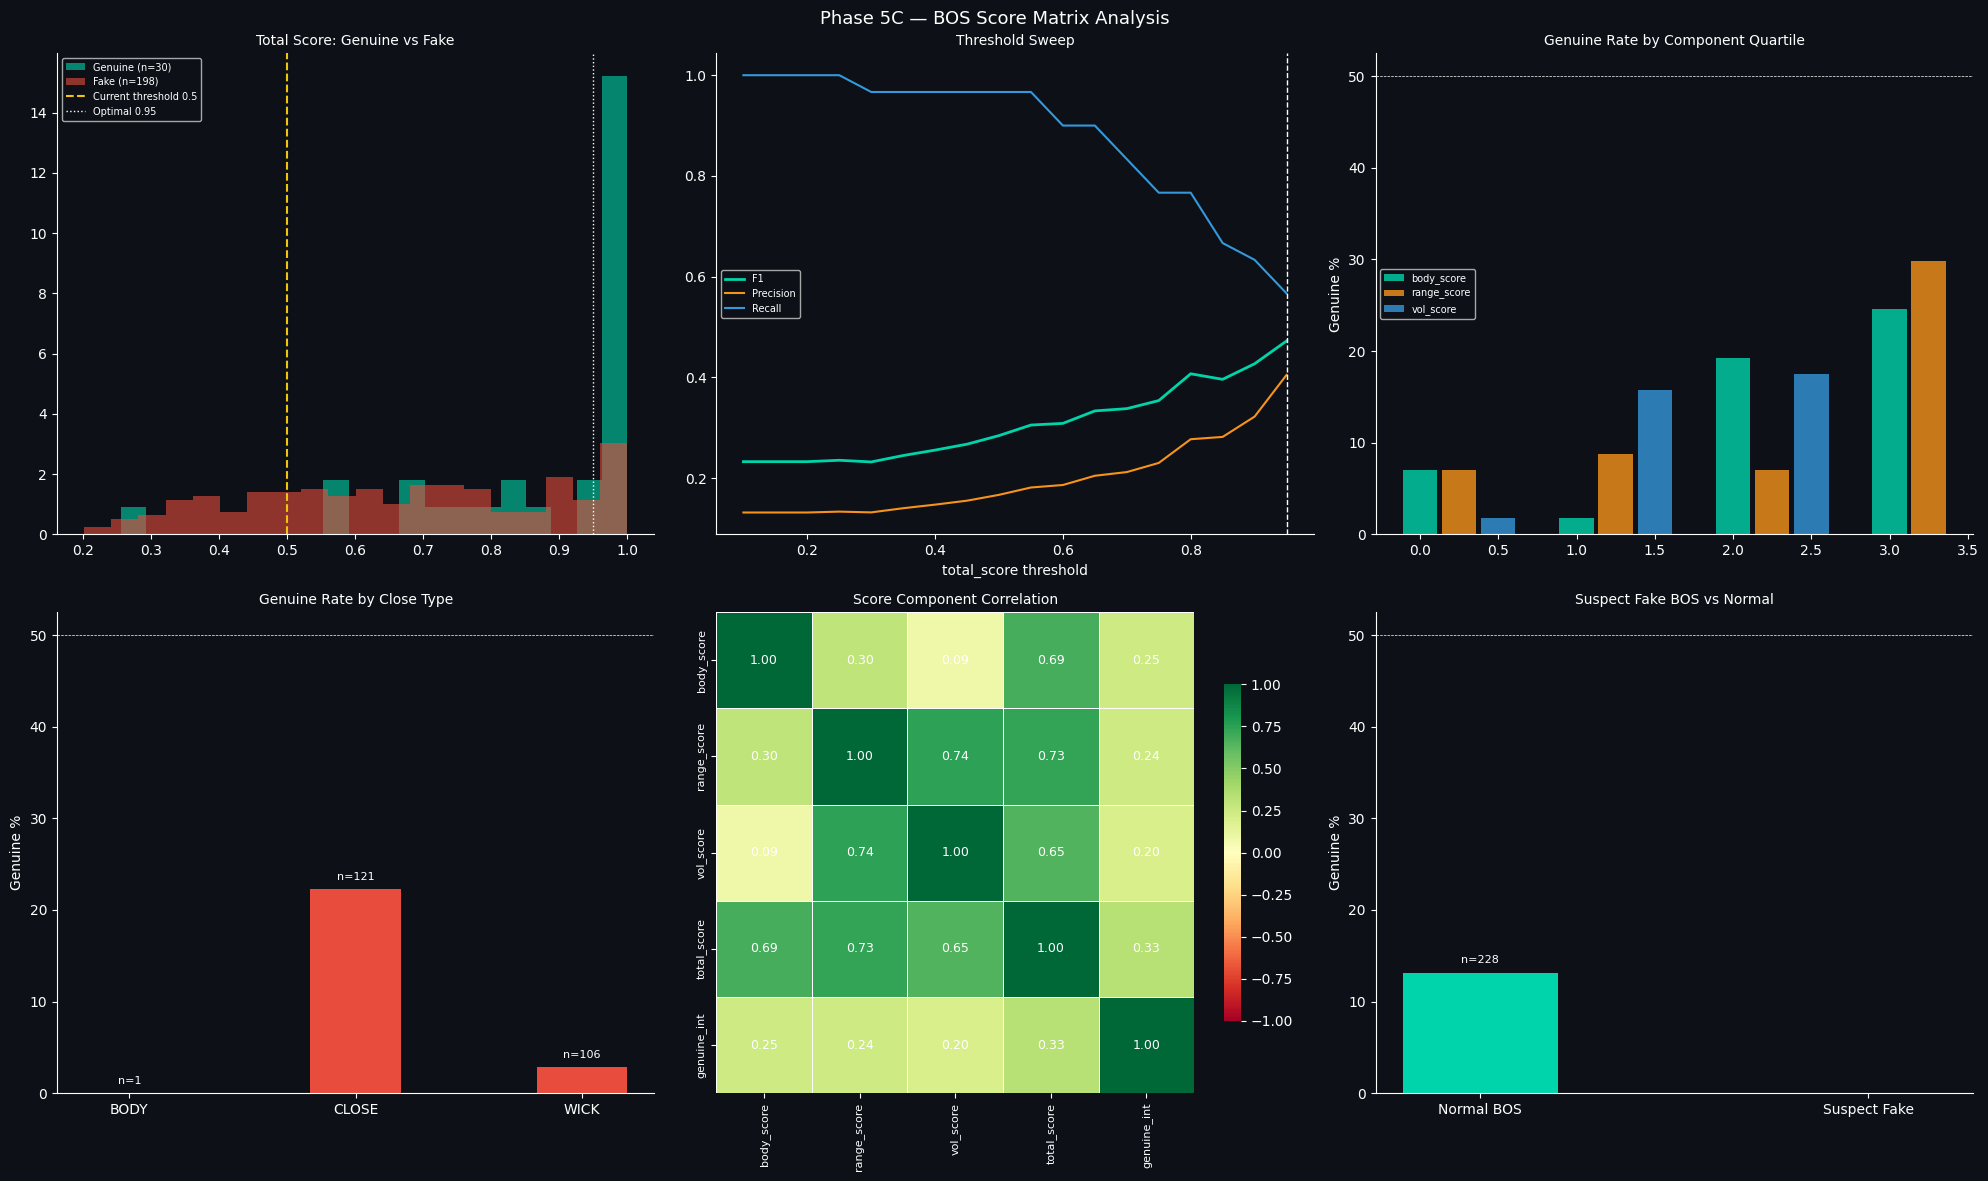

Phase 5C complete.


In [7]:
# ── Phase 5C: Score Matrix Analysis ──────────────────────────────────────

if len(bos_df) == 0 or 'genuine' not in bos_df.columns:
    print('Run Phase 5B first.')
else:
    analysis_df = bos_df[bos_df['genuine'].notna()].copy()
    analysis_df['genuine_int'] = analysis_df['genuine'].astype(int)

    BG, TEAL, ORG, RED, BLUE, YEL = (
        CFG['BG'], CFG['TEAL'], CFG['ORANGE'],
        CFG['RED'], CFG['BLUE'], CFG['YELLOW']
    )

    score_cols = ['body_score','range_score','vol_score','disp_score',
                  'close_bonus','total_score']
    score_cols = [c for c in score_cols if c in analysis_df.columns]

    # ── 1. Spearman correlation of each score with genuine outcome ────────
    print('Spearman correlation: score component vs genuine BOS')
    print(f'{"Component":<20} {"ρ":>8} {"p-value":>10}  Signal?')
    print('-'*55)
    spearman_results = {}
    for col in score_cols:
        valid = analysis_df[[col,'genuine_int']].dropna()
        if len(valid) > 10:
            rho, pv = spearmanr(valid[col], valid['genuine_int'])
            spearman_results[col] = (rho, pv)
            flag = '*PREDICTIVE*' if pv < 0.05 and abs(rho) > 0.05 else ''
            print(f'  {col:<20}: ρ={rho:+.4f}  p={pv:.4f}  {flag}')

    # ── 2. Genuine rate by close_type (WICK / CLOSE / BODY) ───────────────
    print()
    print('Genuine BOS rate by close type:')
    if 'close_type' in analysis_df.columns:
        for ct in ['WICK','CLOSE','BODY']:
            sub = analysis_df[analysis_df['close_type']==ct]
            if len(sub) >= 3:
                gr = sub['genuine'].mean()
                print(f'  {ct:<8}: {gr*100:.1f}% genuine  (n={len(sub)})')

    # ── 3. Threshold sweep on total_score ─────────────────────────────────
    # Find the threshold that maximises F1 score (precision × recall balance)
    print()
    print('Threshold sweep on total_score (finding optimal cutoff):')
    thresholds = np.arange(0.1, 1.0, 0.05)
    sweep_results = []
    for thr in thresholds:
        predicted_genuine = analysis_df['total_score'] >= thr
        actual_genuine    = analysis_df['genuine'] == True
        tp = (predicted_genuine & actual_genuine).sum()
        fp = (predicted_genuine & ~actual_genuine).sum()
        fn = (~predicted_genuine & actual_genuine).sum()
        precision = tp / (tp + fp + 1e-10)
        recall    = tp / (tp + fn + 1e-10)
        f1        = 2 * precision * recall / (precision + recall + 1e-10)
        n_traded  = predicted_genuine.sum()
        sweep_results.append({
            'threshold': thr, 'precision': precision,
            'recall': recall, 'f1': f1, 'n_traded': n_traded
        })

    sweep_thr = pd.DataFrame(sweep_results)
    best_row  = sweep_thr.loc[sweep_thr['f1'].idxmax()]
    print(sweep_thr[['threshold','precision','recall','f1','n_traded']].to_string(index=False))
    print(f'\nOptimal threshold: {best_row["threshold"]:.2f}  '
          f'(F1={best_row["f1"]:.3f}  precision={best_row["precision"]:.3f}  '
          f'n_traded={int(best_row["n_traded"])})')
    print(f'Current config threshold: {CFG["BOS_VALID_THRESHOLD"]}')
    print(f'Suggestion: update BOS_VALID_THRESHOLD in Cell 2 to {best_row["threshold"]:.2f}')

    # ── 4. Score matrix heatmap ───────────────────────────────────────────
    # Split into quartiles of total_score and show genuine rate per quartile
    print()
    print('Genuine rate by total_score quartile:')
    analysis_df['score_quartile'] = pd.qcut(
        analysis_df['total_score'], q=4,
        labels=['Q1 (low)','Q2','Q3','Q4 (high)'], duplicates='drop'
    )
    qgrp = analysis_df.groupby('score_quartile')['genuine'].mean()
    for q, gr in qgrp.items():
        n = (analysis_df['score_quartile']==q).sum()
        print(f'  {q}: {gr*100:.1f}% genuine  (n={n})')

    # ── 5. Interaction: do high-score BOS events also have better fwd return?
    print()
    print('Mean forward return by score quartile (genuine BOS only):')
    gen_only = analysis_df[analysis_df['genuine']==True]
    if 'score_quartile' in gen_only.columns and len(gen_only) > 10:
        for fwd in CFG['BOS_FWD_BARS'][:2]:
            col = f'fwd_{fwd}'
            if col in gen_only.columns:
                q_ret = gen_only.groupby('score_quartile')[col].mean()
                print(f'  {fwd}-bar fwd:')
                for q, ret in q_ret.items():
                    print(f'    {q}: {ret:+.4f}%')

    # ── 6. Plots ──────────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.patch.set_facecolor(BG)
    fig.suptitle('Phase 5C — BOS Score Matrix Analysis', color='white', fontsize=13)

    # Plot 1: Total score distribution genuine vs fake
    ax = axes[0,0]; ax.set_facecolor(BG)
    gen_scores  = analysis_df[analysis_df['genuine']==True]['total_score']
    fake_scores = analysis_df[analysis_df['genuine']==False]['total_score']
    ax.hist(gen_scores,  bins=20, color=TEAL, alpha=0.6, density=True,
            label=f'Genuine (n={len(gen_scores)})')
    ax.hist(fake_scores, bins=20, color=RED,  alpha=0.6, density=True,
            label=f'Fake (n={len(fake_scores)})')
    ax.axvline(CFG['BOS_VALID_THRESHOLD'], color=YEL, lw=1.5, ls='--',
               label=f'Current threshold {CFG["BOS_VALID_THRESHOLD"]}')
    ax.axvline(best_row['threshold'], color='white', lw=1, ls=':',
               label=f'Optimal {best_row["threshold"]:.2f}')
    ax.set_title('Total Score: Genuine vs Fake', color='white', fontsize=10)
    ax.legend(fontsize=7, labelcolor='white', facecolor=BG)
    ax.tick_params(colors='white'); ax.spines[['top','right']].set_visible(False)

    # Plot 2: Threshold sweep F1
    ax = axes[0,1]; ax.set_facecolor(BG)
    ax.plot(sweep_thr['threshold'], sweep_thr['f1'],       color=TEAL, lw=2,  label='F1')
    ax.plot(sweep_thr['threshold'], sweep_thr['precision'], color=ORG,  lw=1.5, label='Precision')
    ax.plot(sweep_thr['threshold'], sweep_thr['recall'],    color=BLUE, lw=1.5, label='Recall')
    ax.axvline(best_row['threshold'], color='white', lw=1, ls='--')
    ax.set_title('Threshold Sweep', color='white', fontsize=10)
    ax.set_xlabel('total_score threshold', color='white')
    ax.legend(fontsize=7, labelcolor='white', facecolor=BG)
    ax.tick_params(colors='white'); ax.spines[['top','right']].set_visible(False)

    # Plot 3: Genuine rate by score component quartile (each component separately)
    ax = axes[0,2]; ax.set_facecolor(BG)
    comp_cols = ['body_score','range_score','vol_score']
    comp_cols = [c for c in comp_cols if c in analysis_df.columns]
    colors_c  = [TEAL, ORG, BLUE]
    for ci, col in enumerate(comp_cols):
        try:
            quartiles = pd.qcut(analysis_df[col], q=4, duplicates='drop')
            q_gen = analysis_df.groupby(quartiles)['genuine'].mean()
            x = np.arange(len(q_gen)) + ci * 0.25
            ax.bar(x, q_gen.values * 100, width=0.22,
                   color=colors_c[ci], alpha=0.8, label=col)
        except Exception:
            pass
    ax.axhline(50, color='white', lw=0.5, ls='--')
    ax.set_title('Genuine Rate by Component Quartile', color='white', fontsize=10)
    ax.set_ylabel('Genuine %', color='white')
    ax.legend(fontsize=7, labelcolor='white', facecolor=BG)
    ax.tick_params(colors='white'); ax.spines[['top','right']].set_visible(False)

    # Plot 4: Close type genuine rate
    ax = axes[1,0]; ax.set_facecolor(BG)
    if 'close_type' in analysis_df.columns:
        ct_grp = analysis_df.groupby('close_type')['genuine'].mean()
        ct_n   = analysis_df.groupby('close_type').size()
        cols_c = [TEAL if g > 0.5 else RED for g in ct_grp.values]
        bars   = ax.bar(ct_grp.index, ct_grp.values * 100, color=cols_c, width=0.4)
        for bar, n in zip(bars, ct_n.values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f'n={n}', ha='center', color='white', fontsize=8)
        ax.axhline(50, color='white', lw=0.5, ls='--')
        ax.set_title('Genuine Rate by Close Type', color='white', fontsize=10)
        ax.set_ylabel('Genuine %', color='white')
    ax.tick_params(colors='white'); ax.spines[['top','right']].set_visible(False)

    # Plot 5: Score correlation heatmap (component intercorrelation)
    ax = axes[1,1]; ax.set_facecolor(BG)
    corr_cols = [c for c in ['body_score','range_score','vol_score',
                              'total_score','genuine_int'] if c in analysis_df.columns]
    if len(corr_cols) >= 3:
        corr_mat = analysis_df[corr_cols].corr(method='spearman')
        sns.heatmap(corr_mat, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn',
                    vmin=-1, vmax=1, linewidths=0.5,
                    annot_kws={'size':9,'color':'white'}, cbar_kws={'shrink':0.7})
        ax.set_title('Score Component Correlation', color='white', fontsize=10)
        ax.tick_params(colors='white', labelsize=8)

    # Plot 6: Suspect fake vs normal BOS genuine rate
    ax = axes[1,2]; ax.set_facecolor(BG)
    if 'suspect_fake' in analysis_df.columns:
        sf_grp = analysis_df.groupby('suspect_fake')['genuine'].mean()
        sf_n   = analysis_df.groupby('suspect_fake').size()
        labels_sf = ['Normal BOS','Suspect Fake']
        cols_sf   = [TEAL, RED]
        bars = ax.bar(labels_sf,
                      [sf_grp.get(False, 0)*100, sf_grp.get(True, 0)*100],
                      color=cols_sf, width=0.4)
        for bar, (k, n) in zip(bars, sf_n.items()):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f'n={n}', ha='center', color='white', fontsize=8)
        ax.axhline(50, color='white', lw=0.5, ls='--')
        ax.set_title('Suspect Fake BOS vs Normal', color='white', fontsize=10)
        ax.set_ylabel('Genuine %', color='white')
    ax.tick_params(colors='white'); ax.spines[['top','right']].set_visible(False)

    plt.tight_layout()
    if CFG['SAVE_PLOTS']:
        plt.savefig('phase5c_bos_matrix.png', dpi=CFG['PLOT_DPI'],
                    bbox_inches='tight', facecolor=BG)
    plt.show()
    print('Phase 5C complete.')

## Summary — BOS Analysis Findings
Prints all empirical findings in one block.
Use these numbers to update CFG['BOS_VALID_THRESHOLD'] and the score weights.

In [8]:
# ── Summary ───────────────────────────────────────────────────────────────

sep = '='*70
print(sep)
print('  SWING STRUCTURE & BOS ANALYSIS — SUMMARY')
print(sep)

if len(bos_df) > 0:
    valid_out = bos_df[bos_df['genuine'].notna()]

    print(f'\nDATA')
    print(f'  Timeframe    : {CFG["STRUCTURE_TF"]}')
    print(f'  Period       : {df_struct.index[0].date()} → {df_struct.index[-1].date()}')
    print(f'  Total bars   : {len(df_struct):,}')

    print(f'\nSWING LEVELS')
    if len(swing_df) > 0:
        print(f'  Total        : {len(swing_df):,}')
        print(f'  Major        : {swing_df["major"].sum():,}')
        print(f'  Minor        : {(~swing_df["major"]).sum():,}')

    print(f'\nBOS EVENTS')
    print(f'  Total detected    : {len(bos_df):,}')
    print(f'  Above threshold   : {bos_df["valid"].sum():,}')
    print(f'  Genuine (measured): {(valid_out["genuine"]==True).sum():,} '
          f'({(valid_out["genuine"]==True).mean()*100:.1f}%)')
    print(f'  Fake              : {(valid_out["genuine"]==False).sum():,} '
          f'({(valid_out["genuine"]==False).mean()*100:.1f}%)')

    print(f'\nSCORE PREDICTIVENESS (Spearman ρ vs genuine outcome)')
    for col, (rho, pv) in spearman_results.items():
        sig = '*' if pv < 0.05 else ''
        print(f'  {col:<20}: ρ={rho:+.4f}  p={pv:.4f} {sig}')

    print(f'\nGENUINE RATE BY CLOSE TYPE')
    if 'close_type' in valid_out.columns:
        for ct in ['WICK','CLOSE','BODY']:
            sub = valid_out[valid_out['close_type']==ct]
            if len(sub) >= 3:
                print(f'  {ct:<8}: {sub["genuine"].mean()*100:.1f}%  (n={len(sub)})')

    print(f'\nTHRESHOLD CALIBRATION')
    print(f'  Current threshold : {CFG["BOS_VALID_THRESHOLD"]}')
    if 'best_row' in dir():
        print(f'  Optimal threshold : {best_row["threshold"]:.2f}  '
              f'(F1={best_row["f1"]:.3f})')
        if abs(best_row['threshold'] - CFG['BOS_VALID_THRESHOLD']) > 0.05:
            print(f'  ACTION: Update BOS_VALID_THRESHOLD to {best_row["threshold"]:.2f} in Cell 2')
        else:
            print(f'  Current threshold is close to optimal. No change needed.')

    print(f'\nFORWARD RETURNS AT GENUINE BOS')
    gen_only = valid_out[valid_out['genuine']==True]
    for fwd in CFG['BOS_FWD_BARS']:
        col = f'fwd_{fwd}'
        if col in gen_only.columns:
            m = gen_only[col].mean()
            w = (gen_only[col] > 0).mean() * 100
            print(f'  {fwd:>3} bars: mean={m:+.4f}%  win%={w:.1f}%')

print()
print(sep)
print('  Next steps:')
print('  1. Update BOS_VALID_THRESHOLD in Cell 2 with optimal value above')
print('  2. Run on longer dataset (180+ days) for more robust calibration')
print('  3. Add aggTrades path to get real delta at BOS bars')
print('  4. Combine BOS genuine filter with volume profile levels from observation notebook')
print(sep)

  SWING STRUCTURE & BOS ANALYSIS — SUMMARY

DATA
  Timeframe    : 5min
  Period       : 2021-01-01 → 2021-12-31
  Total bars   : 105,101

SWING LEVELS
  Total        : 47,616
  Major        : 6
  Minor        : 47,610

BOS EVENTS
  Total detected    : 228
  Above threshold   : 174
  Genuine (measured): 30 (13.2%)
  Fake              : 198 (86.8%)

SCORE PREDICTIVENESS (Spearman ρ vs genuine outcome)
  body_score          : ρ=+0.2500  p=0.0001 *
  range_score         : ρ=+0.2444  p=0.0002 *
  vol_score           : ρ=+0.1960  p=0.0030 *
  disp_score          : ρ=+0.2977  p=0.0000 *
  close_bonus         : ρ=+0.2810  p=0.0000 *
  total_score         : ρ=+0.3307  p=0.0000 *

GENUINE RATE BY CLOSE TYPE
  WICK    : 2.8%  (n=106)
  CLOSE   : 22.3%  (n=121)

THRESHOLD CALIBRATION
  Current threshold : 0.5
  Optimal threshold : 0.95  (F1=0.472)
  ACTION: Update BOS_VALID_THRESHOLD to 0.95 in Cell 2

FORWARD RETURNS AT GENUINE BOS
    6 bars: mean=+0.8427%  win%=90.0%
   12 bars: mean=+1.0039%  